1. What is unsupervised learning in the context of machine learning?
  - Unsupervised learning is a type of machine learning where the data has no target variable.

2. How does K-Means clustering algorithm work?
  - We provide k, which is number of clusters.
  - Then we choose k random centroid.
  - Assign data points to nearest centroid.
  - Calculate mean of each clusters until centroids stop changing.

3. Explain the concept of a dendrogram in hierarchical clustering.
  - A dendrogram is a tree diagram used to show how clusters are formed in hierarchical clustering.
    - Each leaf represents one data point.
    - Branches show clusters merging.
    - The height of a merge indicates the distance (dissimilarity) between clusters.

4. What is the main difference between K-Means and Hierarchical Clustering?
  - K-Means: You must choose the number of clusters (K) before running the algorithm.
  - Hierarchical clustering: Builds a tree of clusters, and you choose the number of clusters afterward by cutting the dendrogram.

5. What are the advantages of DBSCAN over K-Means?
  - No need to pre-specify the number of clusters.
  - Can find irregular / non-spherical cluster shapes.
  - Handles noise and outliers by marking them separately.
  - Works well when clusters have different sizes.

6. When would you use Silhouette Score in clustering?
  - To check if clusterings are formed properly. Score close to 1 means good.

7. What are the limitations of Hierarchical Clustering?
  - Once clusters are merged or split, it cannot be undone.
  - Sensitive to noise and outliers.
  - Choosing the correct cut in the dendrogram can be difficult.

8. Why is feature scaling important in clustering algorithms like K-Means?
  - K-means calculates the distances so huge values will dominate. So, scaling is important.

9. How does DBSCAN identify noise points?
  - DBSCAN checks how many neighbors a point has within a given radius (eps).
  - If a point has fewer than the minimum required neighbors (minPts), it is labeled as noise (outlier).

10. Define inertia in the context of K-Means.
  - Inertia is sum of distances within cluster.

11. What is the elbow method in K-Means clustering?
  - To find the best k, we try every k and plot it.
  - We choose k from where line becomes constant.

12. Describe the concept of "density" in DBSCAN.
  - Density in DBSCAN means how many data points lie close to each other in a region.

13. Can hierarchical clustering be used on categorical data?
  - Yes

14. What does a negative Silhouette Score indicate?
  - Bad clustering

15. Explain the term "linkage criteria" in hierarchical clustering.
  - Linkage criteria is the rule used to measure the distance between clusters in hierarchical clustering.
  - It decides which clusters should be merged.

16. Why might K-Means clustering perform poorly on data with varying cluster sizes or densities?
  - K-Means assumes clusters are roughly equal in size and spherical.

17. What are the core parameters in DBSCAN, and how do they influence clustering?
  - eps: Handles the radius of circle from data point.
  - minPts: Handles how many points should be inside circle.

18. How does K-Means++ improve upon standard K-Means initialization?
  - Instead of placing centroids completely at random, K-Means++ spreads them far apart at the start.

19. What is agglomerative clustering?
  - Agglomerative clustering is a type of hierarchical clustering that follows a bottom to up approach.

20. What makes Silhouette Score a better metric than just inertia for model evaluation?
  - Inertia measures how close points are to their own centroid only.
  - Silhouette Score checks both:
    - how close a point is to its own cluster, and
    - how far it is from other clusters.

In [1]:
import numpy as np

np.random.seed(5)

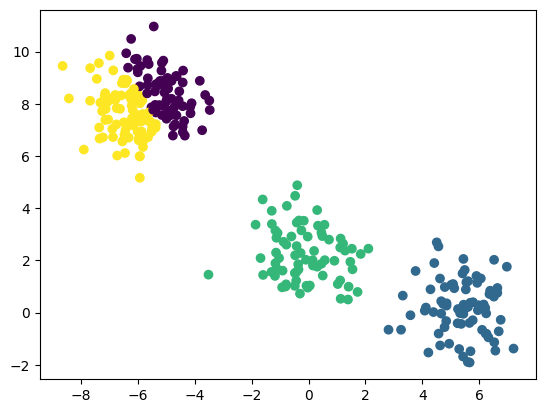

In [2]:
# 21. Generate synthetic data with 4 centers using make_blobs and
# apply K-Means clustering. Visualize using a scatter plot
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X, y = make_blobs(n_samples=300, centers=4)

model = KMeans(n_clusters=4)
pred = model.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=pred)
plt.show()

In [3]:
# 22. Load the Iris dataset and use Agglomerative Clustering to group the data into 3 clusters.
# Display the first 10 predicted labels
from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering

X, y = load_iris(return_X_y=True)

model = AgglomerativeClustering(n_clusters=3)
pred = model.fit_predict(X)

pred[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

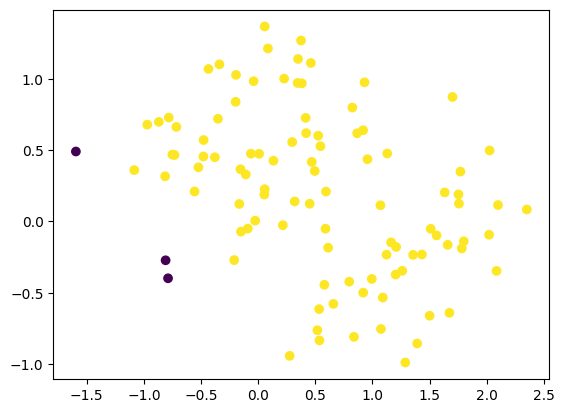

In [4]:
# 23. Generate synthetic data using make_moons and apply DBSCAN.
# Highlight outliers in the plot
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

X, y = make_moons(n_samples=100, noise=0.3)

model = DBSCAN()
pred = model.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=pred)
plt.show()
# purple is outlier

In [5]:
# 24. Load the Wine dataset and apply K-Means clustering after standardizing the features.
# Print the size of each cluster
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X, y = load_wine(return_X_y=True)

scaler = StandardScaler()
X = scaler.fit_transform(X)

model = KMeans(n_clusters=3)
model.fit_predict(X)
lables = model.labels_

unique, counts = np.unique(lables, return_counts=True)

for c, size in zip(unique, counts):
    print(f"Cluster {c}: {size} points")

Cluster 0: 62 points
Cluster 1: 51 points
Cluster 2: 65 points


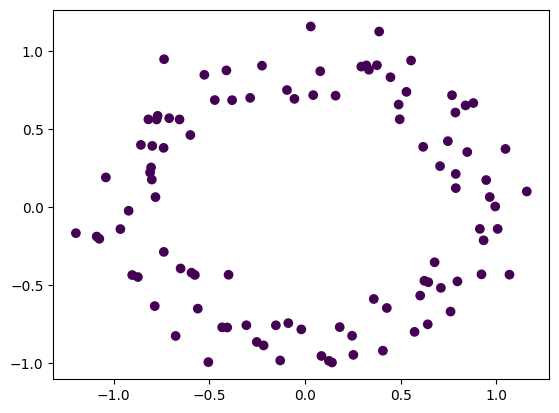

In [6]:
# 25. Use make_circles to generate synthetic data and cluster it using DBSCAN.
# Plot the result
from sklearn.datasets import make_circles
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

X, y = make_circles(n_samples=100, noise=0.1)

model = DBSCAN()
pred = model.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=pred)
plt.show()

In [7]:
# 26. Load the Breast Cancer dataset, apply MinMaxScaler, and use K-Means with 2 clusters.
# Output the cluster centroids
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

X, y = load_breast_cancer(return_X_y=True)

scaler = MinMaxScaler()
X = scaler.fit_transform(X)

model = KMeans(n_clusters=2)
model.fit_predict(X)

model.cluster_centers_

array([[0.25535358, 0.28833455, 0.24696416, 0.14388369, 0.35743076,
        0.18019471, 0.10344776, 0.1306603 , 0.34011829, 0.25591606,
        0.06427485, 0.18843043, 0.05975663, 0.02870108, 0.18158628,
        0.13242941, 0.05821528, 0.18069336, 0.17221057, 0.08403996,
        0.2052406 , 0.32069002, 0.19242138, 0.09943446, 0.3571115 ,
        0.14873935, 0.13142287, 0.26231363, 0.22639412, 0.15437354],
       [0.50483563, 0.39560329, 0.50578661, 0.36376576, 0.46988732,
        0.42226302, 0.41838662, 0.46928035, 0.45899738, 0.29945886,
        0.19093085, 0.19112073, 0.17903433, 0.13086432, 0.18017962,
        0.25890126, 0.12542475, 0.30942779, 0.190072  , 0.13266975,
        0.48047448, 0.45107371, 0.4655302 , 0.31460597, 0.49868817,
        0.36391461, 0.39027292, 0.65827197, 0.33752296, 0.26041387]])

In [8]:
# 27. Generate synthetic data using make_blobs with varying cluster standard deviations
#  and cluster with DBSCAN
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN

X, y = make_blobs(n_samples=300, centers=3, cluster_std=[0.5, 0.25, 1.0])

model = DBSCAN()
pred = model.fit_predict(X)

[[ -1.25946645 -21.27488348]
 [  7.9576113   20.76869896]
 [  6.99192297   9.95598641]
 ...
 [ 10.8012837    6.96025223]
 [ -4.87210009 -12.42395362]
 [ -0.34438963  -6.36554919]]


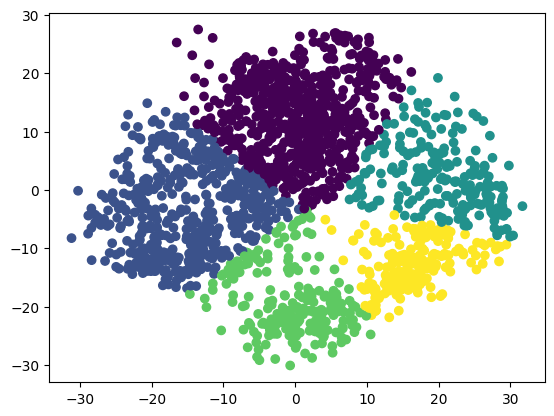

In [9]:
# 28. Load the Digits dataset, reduce it to 2D using PCA,
# and visualize clusters from K-Means
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X, y = load_digits(return_X_y=True)

pca = PCA(n_components=2)
X = pca.fit_transform(X)

model = KMeans(n_clusters=5)
pred = model.fit_predict(X)

print(X)
plt.scatter(X[:,0], X[:,1], c=pred)
plt.show()

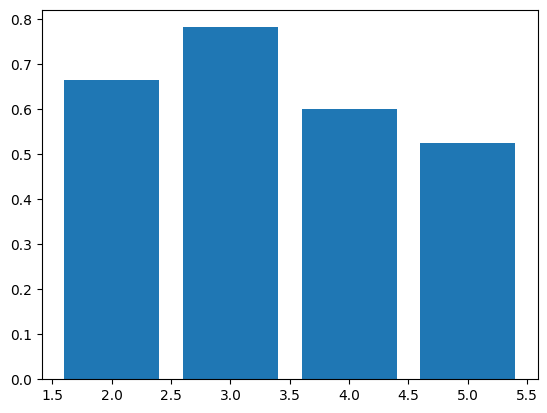

In [10]:
# 29. Create synthetic data using make_blobs and evaluate silhouette scores for k = 2 to 5.
# Display as a bar chart
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

X, y = make_blobs(n_samples=100, centers=3)

scores = []

for i in range(2, 6):
  model = KMeans(n_clusters=i)
  pred = model.fit_predict(X)
  score = silhouette_score(X, pred)
  scores.append(score)

plt.bar(range(2, 6), scores)
plt.show()

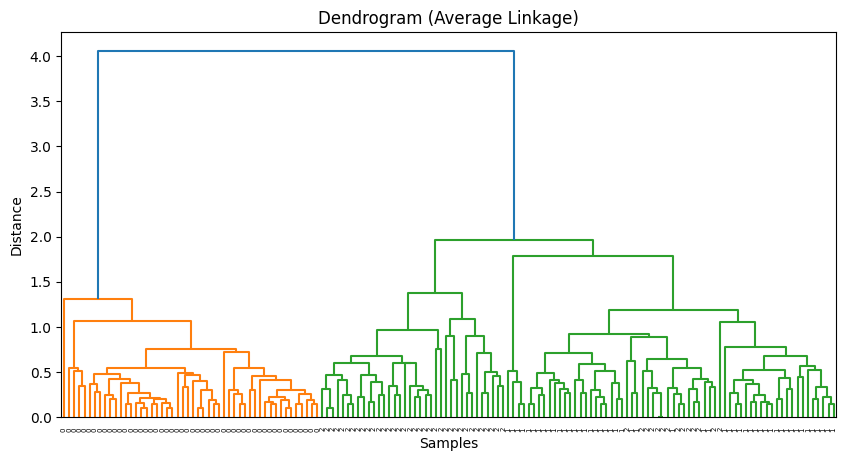

In [11]:
# 30. Load the Iris dataset and use hierarchical clustering to group data.
# Plot a dendrogram with average linkage
from sklearn.datasets import load_iris
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

X, y = load_iris(return_X_y=True)

Z = linkage(X, method="average")

plt.figure(figsize=(10, 5))
dendrogram(Z, labels=y)
plt.title("Dendrogram (Average Linkage)")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

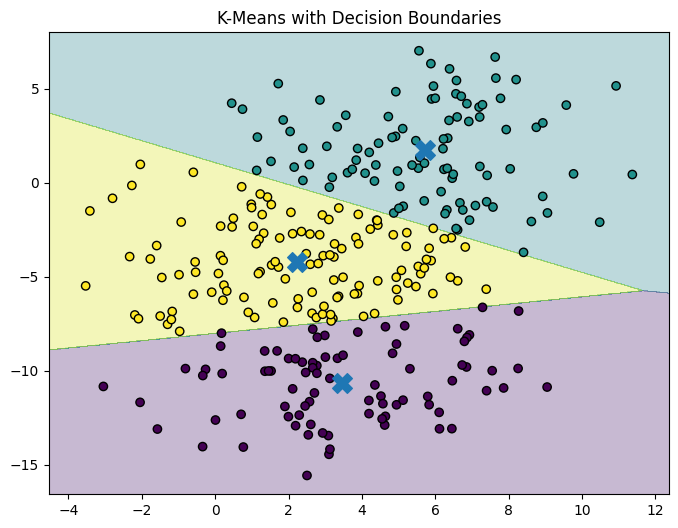

In [12]:
# 31. Generate synthetic data with overlapping clusters using make_blobs, then apply K-Means
#  and visualize with decision boundaries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

X, y = make_blobs(n_samples=300, centers=3, cluster_std=2.5)

model = KMeans(n_clusters=3)
model.fit(X)

h = 0.02
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=model.labels_, edgecolor="k")
plt.scatter(model.cluster_centers_[:, 0],
            model.cluster_centers_[:, 1],
            marker="X", s=200)
plt.title("K-Means with Decision Boundaries")
plt.show()

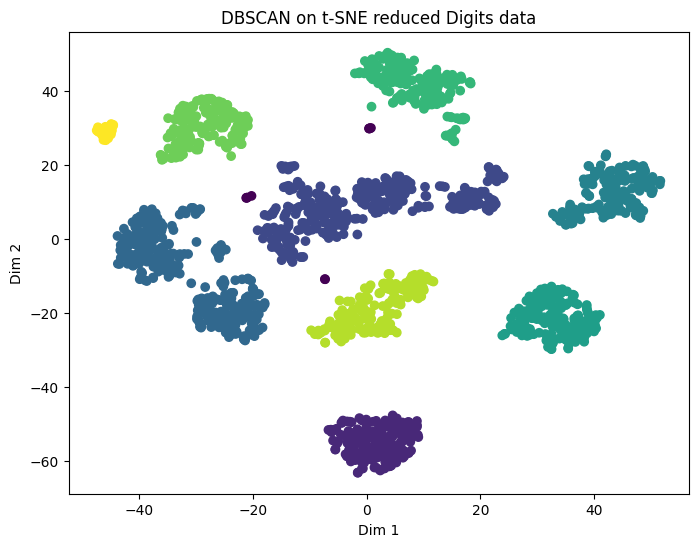

In [13]:
# 32. Load the Digits dataset and apply DBSCAN after reducing dimensions with t-SNE.
#  Visualize the results
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN

digits = load_digits()
X = digits.data

tsne = TSNE(n_components=2)
X_embedded = tsne.fit_transform(X)

model = DBSCAN(eps=5, min_samples=5)
labels = model.fit_predict(X_embedded)

plt.figure(figsize=(8, 6))
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=labels)
plt.title("DBSCAN on t-SNE reduced Digits data")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()

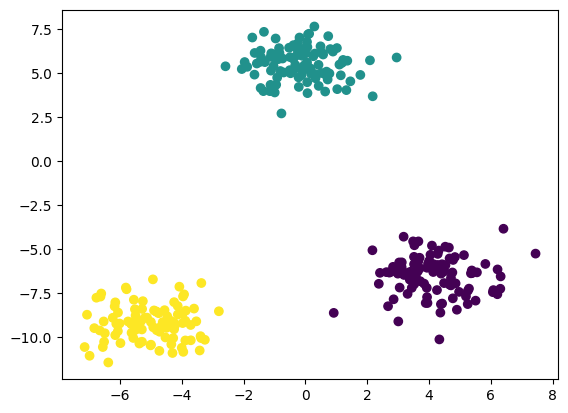

In [14]:
# 33. Generate synthetic data using make_blobs and apply Agglomerative Clustering
# with complete linkage. Plot the result
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

X, y = make_blobs(n_samples=300, centers=3)

model = AgglomerativeClustering(n_clusters=3, linkage="complete")
pred = model.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=pred)
plt.show()

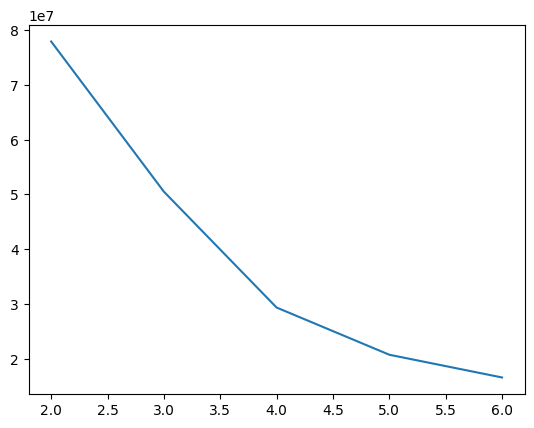

In [15]:
# 34. Load the Breast Cancer dataset and compare inertia values for K = 2 to 6 using K-Means.
# Show results in a line plot
from sklearn.datasets import load_breast_cancer
from sklearn.cluster import KMeans

X, y = load_breast_cancer(return_X_y=True)

wcss = []

for i in range(2, 7):
  model = KMeans(n_clusters=i)
  model.fit_predict(X)
  wcss.append(model.inertia_)

plt.plot(range(2, 7), wcss)
plt.show()

In [16]:
# 35. Generate synthetic concentric circles using make_circles and cluster using
# Agglomerative Clustering with single linkage
from sklearn.datasets import make_circles
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

X, y = make_circles(n_samples=100)

model = AgglomerativeClustering(n_clusters=2, linkage="single")
pred = model.fit_predict(X)

In [17]:
# 36. Use the Wine dataset, apply DBSCAN after scaling the data, and count
#  the number of clusters (excluding noise)
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

X, y = load_wine(return_X_y=True)

scaler = StandardScaler()
X = scaler.fit_transform(X)

model = DBSCAN(eps=2)
pred = model.fit_predict(X)

clusters = len(set(pred)) - (1 if -1 in pred else 0)

print("Number of clusters:", clusters)

Number of clusters: 5


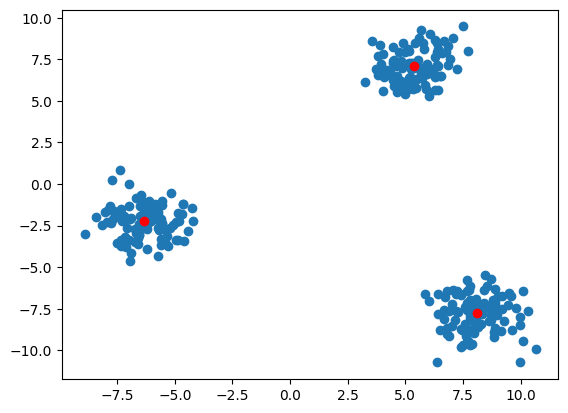

In [18]:
# 37. Generate synthetic data with make_blobs and apply KMeans.
# Then plot the cluster centers on top of the data points
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X, y = make_blobs(n_samples=300, centers=3)

model = KMeans(n_clusters=3)
model.fit_predict(X)

plt.scatter(X[:,0], X[:,1])
plt.scatter(model.cluster_centers_[:,0],
            model.cluster_centers_[:,1],
            c="red")
plt.show()


In [19]:
# 38. Load the Iris dataset, cluster with DBSCAN, and print how many samples were identified as noise
from sklearn.datasets import load_iris
from sklearn.cluster import DBSCAN

X, y = load_iris(return_X_y=True)

model = DBSCAN()
pred = model.fit_predict(X)

noise = sum(pred == -1)
noise

np.int64(17)

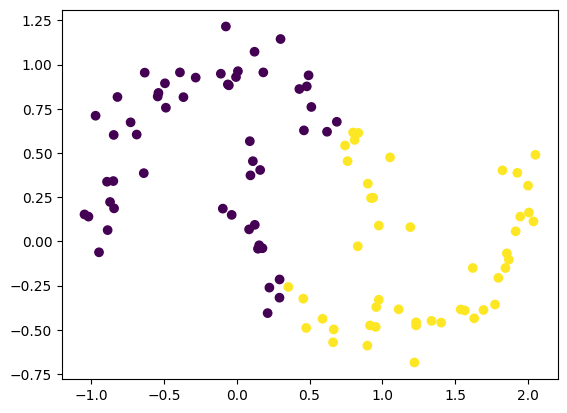

In [20]:
# 39. Generate synthetic non-linearly separable data using make_moons, apply K-Means,
#  and visualize the clustering result
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X, y = make_moons(n_samples=100, noise=0.1)

model = KMeans(n_clusters=2)
pred = model.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=pred)
plt.show()

In [21]:
# 40. Load the Digits dataset, apply PCA to reduce to 3 components, then use KMeans
# and visualize with a 3D scatter plot.
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import plotly.express as px

X, y = load_digits(return_X_y=True)

pca = PCA(n_components=3)
X = pca.fit_transform(X)

model = KMeans(n_clusters=5)
pred = model.fit_predict(X)

fig = px.scatter_3d(x=X[:, 0], y=X[:, 1], z=X[:, 2], color=pred)
fig.show()

In [22]:
# 41. Generate synthetic blobs with 5 centers and apply KMeans.
# Then use silhouette_score to evaluate the clustering
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X, y = make_blobs(n_samples=300, centers=5)

model = KMeans(n_clusters=5)
pred = model.fit_predict(X)

score = silhouette_score(X, pred)
score

np.float64(0.619883369776483)

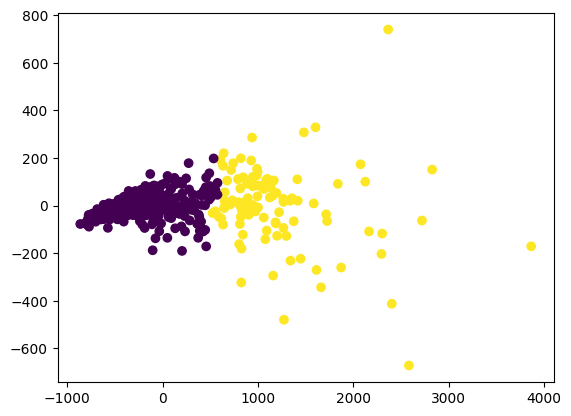

In [23]:
# 42. Load the Breast Cancer dataset, reduce dimensionality using PCA,
# and apply Agglomerative Clustering. Visualize in 2D
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

X, y = load_breast_cancer(return_X_y=True)

pca = PCA(n_components=2)
X = pca.fit_transform(X)

model = AgglomerativeClustering(n_clusters=2)
pred = model.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=pred)
plt.show()

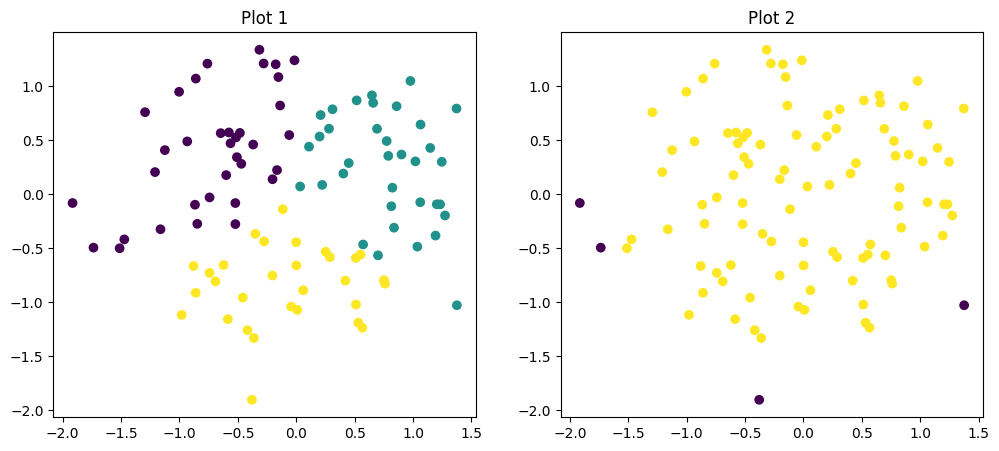

In [24]:
# 43. Generate noisy circular data using make_circles and visualize clustering results from KMeans
# and DBSCAN side-by-side
from sklearn.datasets import make_circles
from sklearn.cluster import KMeans, DBSCAN
import matplotlib.pyplot as plt

X, y = make_circles(n_samples=100, noise=0.4)

k_model = KMeans(n_clusters=3)
k_pred = k_model.fit_predict(X)

d_model = DBSCAN(eps=0.5)
d_pred = d_model.fit_predict(X)

fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(1, 2, 1)
ax1.scatter(X[:, 0], X[:, 1], c=k_pred)
ax1.set_title("Plot 1")

ax2 = fig.add_subplot(1, 2, 2)
ax2.scatter(X[:, 0], X[:, 1], c=d_pred)
ax2.set_title("Plot 2")

plt.show()

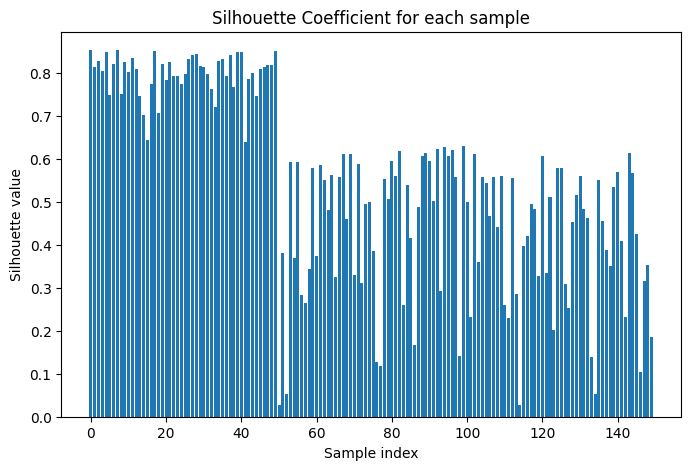

In [25]:
# 44. Load the Iris dataset and plot the Silhouette Coefficient for each sample after KMeans clustering
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples

X, y = load_iris(return_X_y=True)

model = KMeans(n_clusters=3)
pred = model.fit_predict(X)

sample_silhouette = silhouette_samples(X, pred)

plt.figure(figsize=(8, 5))
plt.bar(range(len(sample_silhouette)), sample_silhouette)
plt.title("Silhouette Coefficient for each sample")
plt.xlabel("Sample index")
plt.ylabel("Silhouette value")
plt.show()

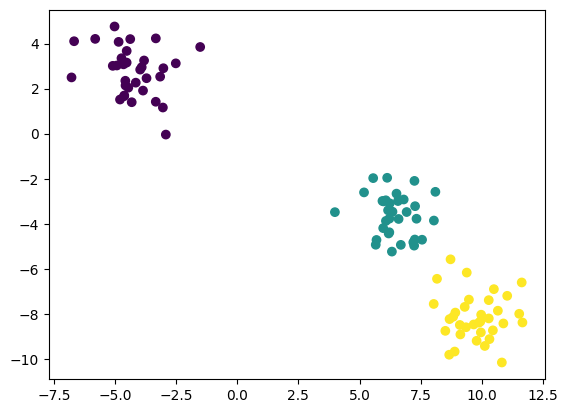

In [26]:
# 45. Generate synthetic data using make_blobs and apply Agglomerative Clustering
#  with 'average' linkage. Visualize clusters
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

X, y = make_blobs(n_samples=100, centers=3)

model = AgglomerativeClustering(n_clusters=3, linkage="average")
pred = model.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=pred)
plt.show()

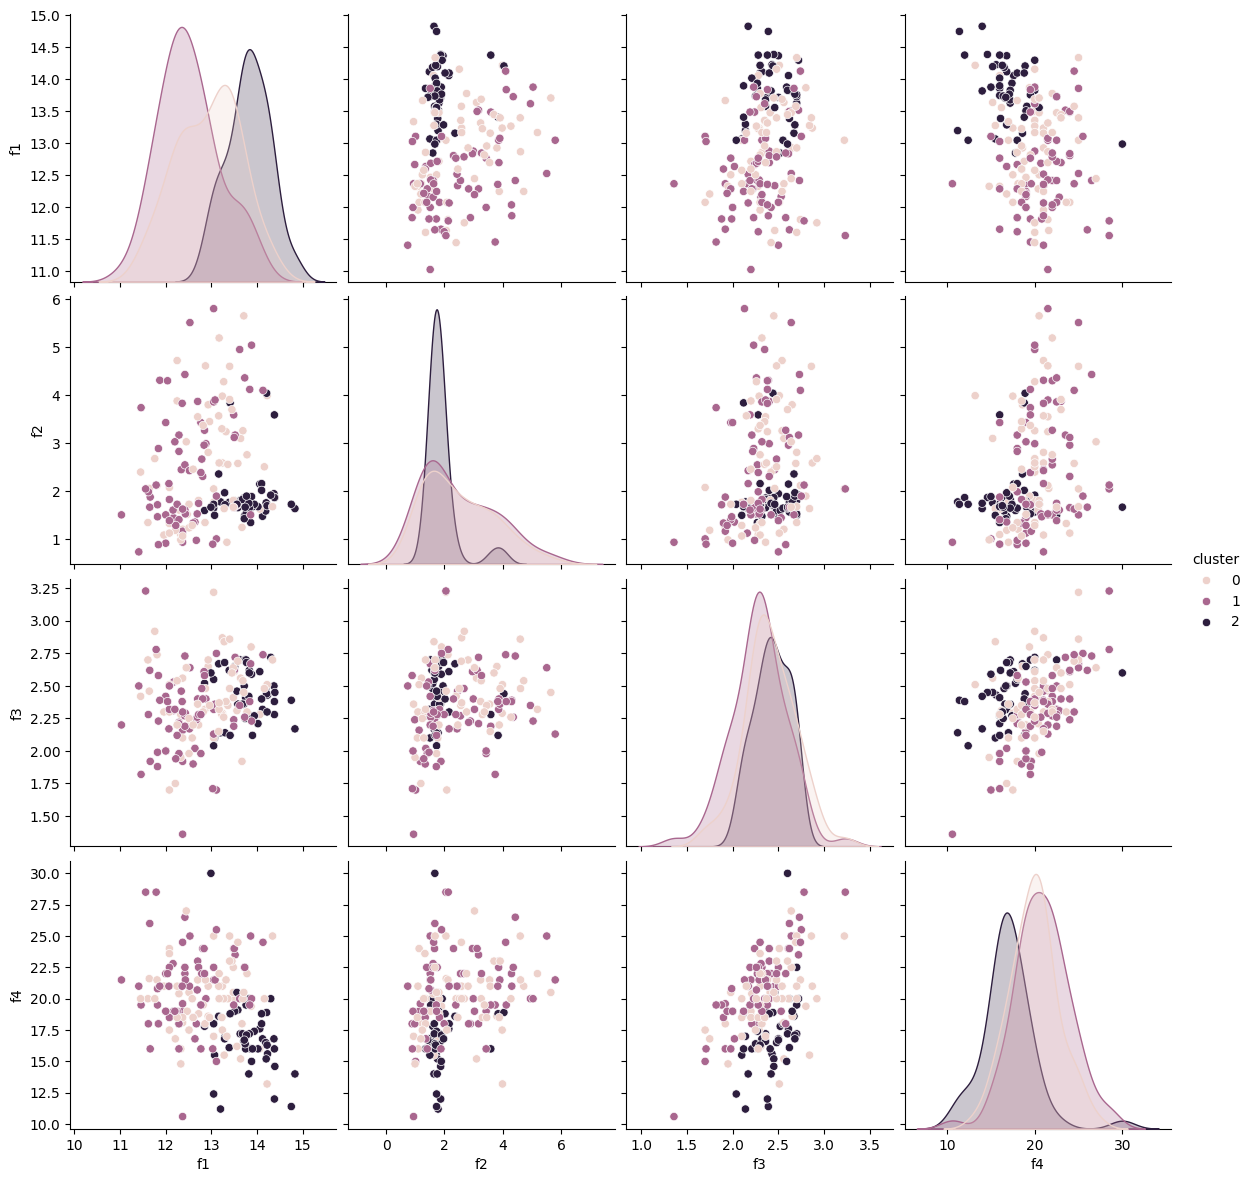

In [27]:
# 46. Load the Wine dataset, apply KMeans, and visualize the cluster assignments
#  in a seaborn pairplot (first 4 features)
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

X, y = load_wine(return_X_y=True)

model = KMeans(n_clusters=3)
pred = model.fit_predict(X)

df = pd.DataFrame(X[:, :4], columns=["f1", "f2", "f3", "f4"])
df["cluster"] = pred

sns.pairplot(df, hue="cluster", height=3)

In [28]:
# 47. Generate noisy blobs using make_blobs and use DBSCAN to identify both clusters
#  and noise points. Print the count
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN

X, _ = make_blobs(n_samples=300, centers=3, cluster_std=2.5)

model = DBSCAN(eps=0.8, min_samples=5)
labels = model.fit_predict(X)

clusters = len(set(labels)) - (1 if -1 in labels else 0)

noise = sum(labels == -1)

print("Clusters:", clusters)
print("Noise points:", noise)

Clusters: 11
Noise points: 162


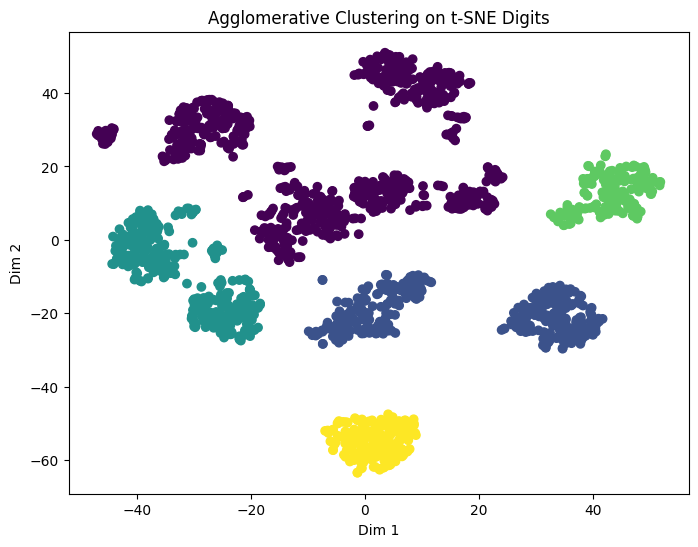

In [29]:
# 48. Load the Digits dataset, reduce dimensions using t-SNE, then apply Agglomerative
#  Clustering and plot the clusters.
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from sklearn.cluster import AgglomerativeClustering

digits = load_digits()
X = digits.data

tsne = TSNE(n_components=2)
X_embedded = tsne.fit_transform(X)

model = AgglomerativeClustering(n_clusters=5)
labels = model.fit_predict(X_embedded)

plt.figure(figsize=(8, 6))
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=labels)
plt.title("Agglomerative Clustering on t-SNE Digits")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()